In [ ]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Note: 'drug_final.csv' was generated using the SQL validation script (Step 2 in SQL validation file)
df = pd.read_csv('drug_final.csv')
print("Data loaded successfully!")


Data loaded successfully!


In [2]:
# Define the two groups
drug_y_group = df[df['Drug'] == 'DrugY']
others_group = df[df['Drug'] != 'DrugY']

# List of numeric features to test
features = ['Age', 'Na_to_K']

# List of categorical features to test
cat_features = ['Sex', 'BP', 'Cholesterol']


# 1. Initialize an empty list to store our results
audit_results = []

# 2. Run Numeric Audit
for f in features:
    t_stat, p_val = stats.ttest_ind(drug_y_group[f], others_group[f], equal_var=False)
    audit_results.append({
        'Feature': f,
        'Test_Type': 'T-Test (Numeric)',
        'P_Value': round(p_val, 10),
        'Significant': p_val < 0.05
    })

# 3. Run Categorical Audit
for c in cat_features:
    contingency = pd.crosstab(df['Drug'] == 'DrugY', df[c])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
    audit_results.append({
        'Feature': c,
        'Test_Type': 'Chi-Square (Categorical)',
        'P_Value': round(p_val, 10),
        'Significant': p_val < 0.05
    })

# 4. Convert the list into a professional Summary Table
summary_df = pd.DataFrame(audit_results)

# 5. Display the final result
summary_df


,Feature,Test_Type,P_Value,Significant
0,Age,T-Test (Numeric),0.660071,False
1,Na_to_K,T-Test (Numeric),0.000000,True
2,Sex,Chi-Square (Categorical),0.422838,False
3,BP,Chi-Square (Categorical),0.467736,False
4,Cholesterol,Chi-Square (Categorical),1.000000,False


C:\Users\Mun Fai\AppData\Local\Temp\ipykernel_31096\2630359902.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Drug', y='Na_to_K', data=df, palette="Set2")


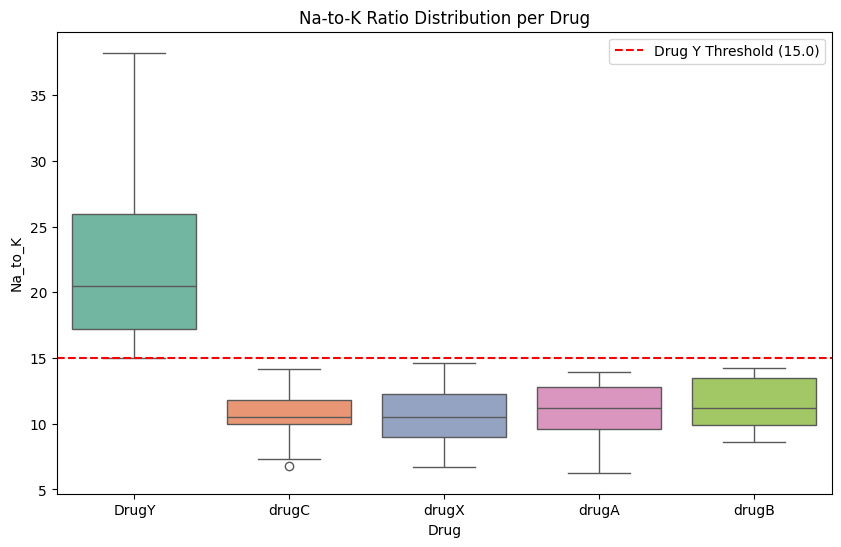

In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Drug', y='Na_to_K', data=df, palette="Set2")
plt.axhline(y=15, color='red', linestyle='--', label='Drug Y Threshold (15.0)')
plt.title('Na-to-K Ratio Distribution per Drug')
plt.legend()
plt.show()



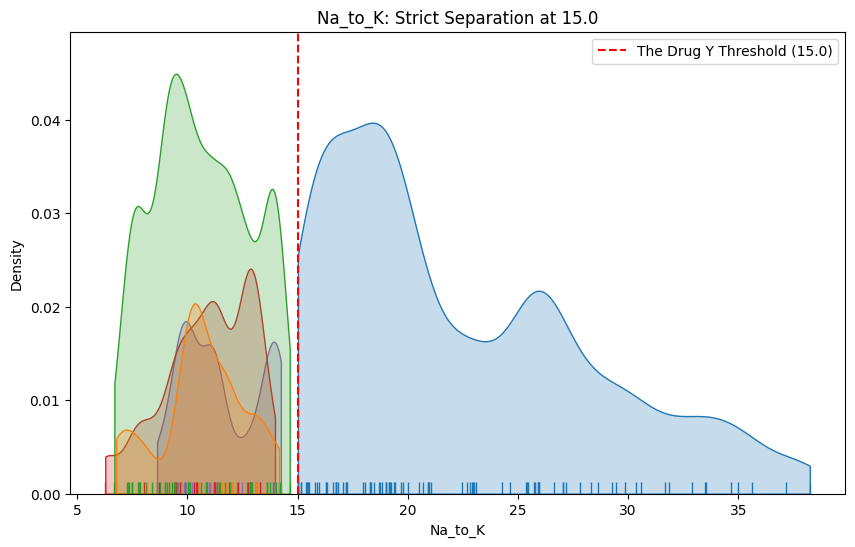

In [4]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Na_to_K', hue='Drug', fill=True, cut=0, bw_adjust=0.5)
sns.rugplot(data=df, x='Na_to_K', hue='Drug')
plt.axvline(x=15, color='red', linestyle='--', label='The Drug Y Threshold (15.0)')
plt.title('Na_to_K: Strict Separation at 15.0')
plt.legend()
plt.show()


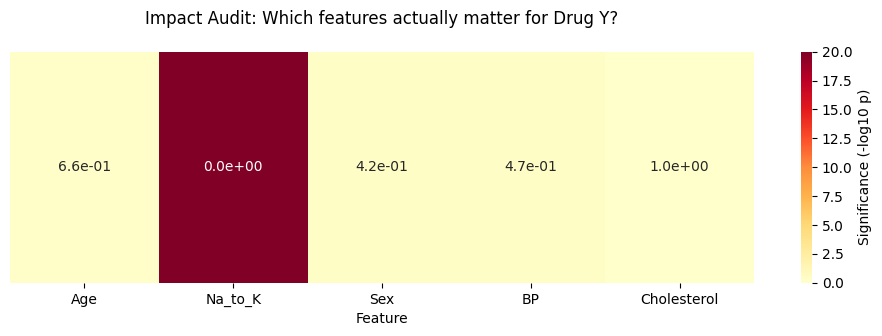

In [5]:
import numpy as np

# 1. Prepare the data from your existing 'audit_results' list
plot_df = pd.DataFrame(audit_results)

# 2. Apply the Log transformation 
plot_df['Impact_Score'] = -np.log10(plot_df['P_Value'] + 1e-20)

# 3. Reshape for the Heatmap (Feature names on X-axis)
heatmap_data = plot_df.set_index('Feature')[['Impact_Score']].T

# 4. Create the Plot
plt.figure(figsize=(12, 3))
sns.heatmap(heatmap_data, 
            annot=plot_df.set_index('Feature')[['P_Value']].T, # Show actual P-values in boxes
            fmt=".1e", # Scientific notation for small numbers
            cmap="YlOrRd", # Yellow-Orange-Red (Red = High Impact)
            cbar_kws={'label': 'Significance (-log10 p)'})

plt.title('Impact Audit: Which features actually matter for Drug Y?', pad=20)
plt.yticks([]) # Hide Y-axis since it's just one row
plt.show()
